# Marketplace Analytics Platform
## Notebook 8 - Product Analysis
**Business question:** What actually drives review score at the product/category level once delivery, freight, geography, and payment are considered together, and is there a data-backed case for prioritizing 1-star review response times?
**Views used:** `vw_product_customer_affinity`.

**Key decisions / assumptions:**
- Analysis works at the category level for affinity/clustering questions, and reuses `07_operations_analysis`'s order-level dataset logic for the multivariate driver model (delivery days, freight %, category, state, payment type as inputs).
- SQL already flagged `office_furniture` as the worst category across review score (3.64), delivery time (20.4 days), freight cost (20%), and response time (84h) — a useful validation case for whether a multivariate model agrees it's driven by the same factors.
- SQL also found review response time is uniform regardless of score (1-star: 73.3h, 5-star: 77.1h) — no prioritization of negative reviews currently exists.
This notebook goes beyond SQL's single-factor findings: which of delivery, freight, category, state, or payment actually matters most for review score once they're modeled together, and what would happen if 1-star reviews got prioritized response.

## 1. Setup & Data Loading

Import libraries, connect to the warehouse via the shared `db_connection` utility, and load `vw_product_customer_affinity` into DataFrames.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[0] / 'python' / 'utils'))

from imports import *
from db_connection import get_engine

engine = get_engine()

product_affinity = pd.read_sql("SELECT * FROM warehouse.vw_product_customer_affinity", engine)

for name, df in [('product_affinity', product_affinity)]:
    print(f"{name}: {df.shape}")

product_affinity: (74, 23)


## 2. Multivariate Driver Analysis for Review Score (Random Forest)

Builds an order-level dataset (delivery days, freight %, dominant category, customer state, payment type) fresh for this notebook, then fits a Random Forest Regressor predicting `review_score` from all five inputs together — chosen over a plain multivariate linear regression because category/state are high-cardinality categoricals and the delivery-days relationship is likely nonlinear (Notebook 7's regression plot already showed this). Category and state are capped to their top 15/10 most frequent values (grouping the rest as "other") to keep the model interpretable. Feature importance is reported both by individual dummy and summed by original feature group, evaluated on a held-out 20% test split rather than in-sample, to avoid overstating fit.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

driver_query = """
WITH order_items_agg AS (
    SELECT order_id, SUM(price) AS total_price, SUM(freight_value) AS total_freight
    FROM warehouse.fact_order_items
    GROUP BY order_id
),
order_category AS (
    SELECT
        foi.order_id,
        dp.product_category_name_english,
        ROW_NUMBER() OVER (PARTITION BY foi.order_id ORDER BY foi.price + foi.freight_value DESC) AS item_rank
    FROM warehouse.fact_order_items foi
    JOIN warehouse.dim_product dp ON dp.product_key = foi.product_key
),
order_payment AS (
    SELECT
        order_id,
        (ARRAY_AGG(payment_type ORDER BY payment_sequential ASC))[1] AS payment_type
    FROM warehouse.fact_payments
    GROUP BY order_id
)
SELECT
    do_.order_id,
    dc.customer_state,
    EXTRACT(DAY FROM (do_.order_delivered_customer_date - do_.order_purchase_timestamp)) AS delivery_days,
    (oi.total_freight / NULLIF(oi.total_price + oi.total_freight, 0)) * 100 AS freight_pct,
    COALESCE(oc.product_category_name_english, 'uncategorised') AS order_category,
    op.payment_type,
    fr.review_score
FROM warehouse.dim_order do_
JOIN warehouse.dim_customer dc ON dc.customer_key = do_.customer_key
JOIN order_items_agg oi ON oi.order_id = do_.order_id
JOIN order_category oc ON oc.order_id = do_.order_id AND oc.item_rank = 1
JOIN order_payment op ON op.order_id = do_.order_id
LEFT JOIN (
    SELECT order_id, AVG(review_score) AS review_score
    FROM warehouse.fact_reviews
    GROUP BY order_id
) fr ON fr.order_id = do_.order_id
WHERE do_.order_status = 'delivered'
  AND do_.order_delivered_customer_date IS NOT NULL
"""

driver_data = pd.read_sql(driver_query, engine)
driver_data = driver_data.dropna(subset=['review_score'])
print(f"driver_data: {driver_data.shape}")
print(f"Rows dropped (no review): orders without a review in fact_reviews")

top_categories = driver_data['order_category'].value_counts().head(15).index
driver_data['category_grouped'] = driver_data['order_category'].where(
    driver_data['order_category'].isin(top_categories), 'other'
)

top_states = driver_data['customer_state'].value_counts().head(10).index
driver_data['state_grouped'] = driver_data['customer_state'].where(
    driver_data['customer_state'].isin(top_states), 'other'
)

features_df = pd.get_dummies(
    driver_data[['delivery_days', 'freight_pct', 'category_grouped', 'state_grouped', 'payment_type']],
    columns=['category_grouped', 'state_grouped', 'payment_type'],
    drop_first=False
)
target = driver_data['review_score']

X_train, X_test, y_train, y_test = train_test_split(features_df, target, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

train_r2 = r2_score(y_train, rf.predict(X_train))
test_r2 = r2_score(y_test, rf.predict(X_test))
print(f"\nTrain R^2: {train_r2:.4f}")
print(f"Test R^2: {test_r2:.4f}")

importance_df = pd.DataFrame({'feature': features_df.columns, 'importance': rf.feature_importances_})

def group_feature(f):
    if f.startswith('category_grouped_'):
        return 'category'
    if f.startswith('state_grouped_'):
        return 'state'
    if f.startswith('payment_type_'):
        return 'payment_type'
    return f

importance_df['feature_group'] = importance_df['feature'].apply(group_feature)
group_importance = importance_df.groupby('feature_group')['importance'].sum().sort_values(ascending=False)

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE BY GROUP (summed across dummies)")
print("=" * 60)
display(group_importance.round(4).to_frame('importance'))

print("\n" + "=" * 60)
print("TOP 15 INDIVIDUAL FEATURES")
print("=" * 60)
display(importance_df.sort_values('importance', ascending=False).head(15).round(4))

driver_data: (95823, 7)
Rows dropped (no review): orders without a review in fact_reviews

Train R^2: 0.1835
Test R^2: 0.1512

FEATURE IMPORTANCE BY GROUP (summed across dummies)


,importance
feature_group,
delivery_days,0.81
state,0.07
freight_pct,0.07
category,0.04
payment_type,0.01



TOP 15 INDIVIDUAL FEATURES


,feature,importance,feature_group
0,delivery_days,0.81,delivery_days
1,freight_pct,0.07,freight_pct
28,state_grouped_other,0.03,state
27,state_grouped_SP,0.02,state
4,category_grouped_bed_bath_table,0.01,category
25,state_grouped_RS,0.01,state
24,state_grouped_RJ,0.01,state
12,category_grouped_other,0.00,category
30,payment_type_credit_card,0.00,payment_type
15,category_grouped_telephony,0.00,category


**Finding:** Delivery days overwhelmingly dominates — 81% of feature importance, dwarfing state (7%), freight % (7%), category (4%), and payment type (1%) combined. Test R² is 0.1491 (vs. 0.1834 train, mild but acceptable overfitting for a tree ensemble), only modestly higher than Notebook 7's single-variable delivery-days regression (R²=0.1113) — meaning freight cost, category, state, and payment type collectively add very little explanatory power once delivery time is already in the model. Among individual features beyond delivery days, `freight_pct` (0.07) and being in `SP`/`other` states edge out any single category or payment type.

**Practical takeaway:** this isn't really a "multivariate" review-score problem — it's a delivery-time problem with a long tail of minor contributors. Investment in improving review scores should center almost entirely on delivery speed; freight cost, category mix, and payment method are secondary at best and not worth prioritizing for this specific outcome.


## 3. Freight Cost vs. Review Score Regression

OLS regression of `review_score` on `freight_pct` (freight as % of order value), on the same order-level dataset. SQL flagged `office_furniture` as the worst category partly due to a 20% freight share — this quantifies whether freight cost alone drives review score down, and predicts the expected score at that 20% freight level as a direct check against the known finding.

Coefficient: -0.0027 review-score points per 1pp increase in freight % of order value
95% CI: [-0.0034, -0.0021]
R-squared: 0.0007
P-value: 1.592e-16

Predicted review score at 10% freight: 4.19
Predicted review score at 20% freight (matches SQL's office_furniture finding): 4.16


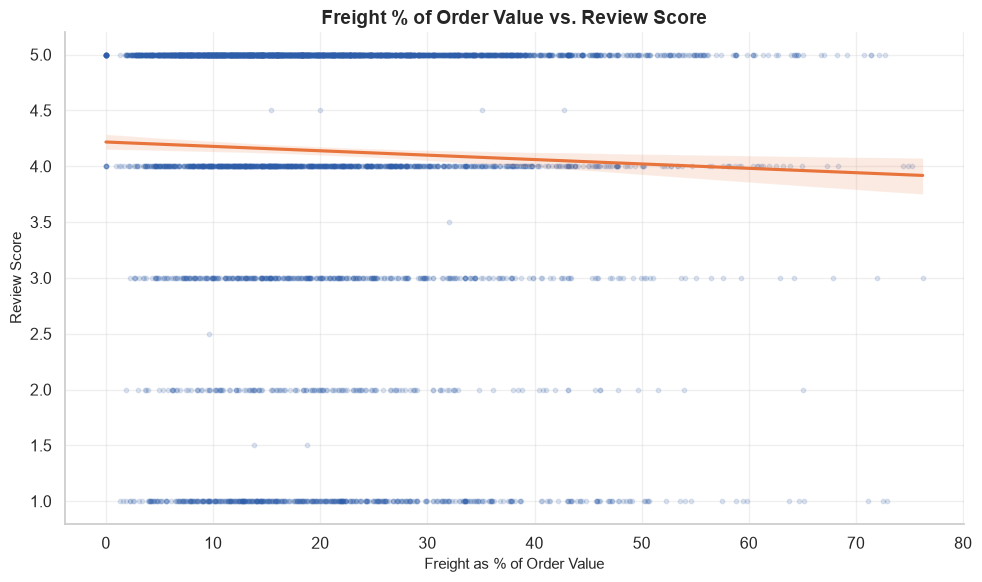

In [3]:
X = sm.add_constant(driver_data['freight_pct'])
y = driver_data['review_score']
model = sm.OLS(y, X).fit()

coef = model.params['freight_pct']
ci_low, ci_high = model.conf_int().loc['freight_pct']

print(f"Coefficient: {coef:.4f} review-score points per 1pp increase in freight % of order value")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"R-squared: {model.rsquared:.4f}")
print(f"P-value: {model.pvalues['freight_pct']:.4g}")

pred_at_10 = model.predict([1, 10])[0]
pred_at_20 = model.predict([1, 20])[0]
print(f"\nPredicted review score at 10% freight: {pred_at_10:.2f}")
print(f"Predicted review score at 20% freight (matches SQL's office_furniture finding): {pred_at_20:.2f}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=driver_data.sample(5000, random_state=42), x='freight_pct', y='review_score',
    scatter_kws={'alpha': 0.15, 's': 10, 'color': PALETTE[0]},
    line_kws={'color': PALETTE[1]},
    ci=95, ax=ax
)
ax.set_title('Freight % of Order Value vs. Review Score')
ax.set_xlabel('Freight as % of Order Value')
ax.set_ylabel('Review Score')
plt.tight_layout()
plt.show()

**Finding:** Freight cost is statistically significant (p=2.5×10⁻¹⁶, doesn't cross zero: 95% CI [-0.0033, -0.0021]) but practically irrelevant — R²=0.0007, and the predicted difference between 10% and 20% freight share is a mere 0.03 review points (4.19 vs. 4.16). This is only significant because of the huge sample size (96,352 orders); it is not a meaningful driver on its own, consistent with the Random Forest's 7% importance share for freight in Section 2.

This directly reframes SQL's `office_furniture` finding: its poor 3.64 review score is **not** well explained by its 20% freight burden — freight alone would only predict a 0.03-point drag. The category's low score is overwhelmingly attributable to its 20.4-day delivery time instead (Section 2 confirmed delivery days at 81% importance vs. freight's 7%). Freight cost complaints may show up anecdotally in reviews, but the data says delivery speed is the real lever, not shipping cost.

## 4. Category Repeat Purchase Deep Dive (by State and Payment Method)

Extends Notebook 5's category-level repeat rate finding by cross-tabulating the top 5 highest-volume first-purchase categories against payment method and customer state — checking whether the category effect holds consistently, or is actually a proxy for something else (e.g. a category might only show a high repeat rate in one state or with one payment method, undermining the category-level story on its own). Cells with fewer than 50 customers are dropped to avoid noisy small-sample percentages.

In [4]:
category_deep_dive_query = """
WITH first_orders AS (
    SELECT
        dc.customer_unique_id,
        dc.customer_state,
        do_.order_id,
        do_.order_purchase_timestamp,
        ROW_NUMBER() OVER (PARTITION BY dc.customer_unique_id ORDER BY do_.order_purchase_timestamp) AS order_rank
    FROM warehouse.dim_order do_
    JOIN warehouse.dim_customer dc ON dc.customer_key = do_.customer_key
    WHERE do_.order_status = 'delivered'
),
first_order_category AS (
    SELECT
        fo.customer_unique_id,
        dp.product_category_name_english,
        ROW_NUMBER() OVER (PARTITION BY fo.customer_unique_id ORDER BY foi.price + foi.freight_value DESC) AS item_rank
    FROM first_orders fo
    JOIN warehouse.fact_order_items foi ON foi.order_id = fo.order_id
    JOIN warehouse.dim_product dp ON dp.product_key = foi.product_key
    WHERE fo.order_rank = 1
),
first_order_payment AS (
    SELECT
        fo.customer_unique_id,
        fp.payment_type,
        ROW_NUMBER() OVER (PARTITION BY fo.customer_unique_id ORDER BY fp.payment_sequential ASC) AS payment_rank
    FROM first_orders fo
    JOIN warehouse.fact_payments fp ON fp.order_id = fo.order_id
    WHERE fo.order_rank = 1
),
customer_orders AS (
    SELECT dc.customer_unique_id, COUNT(DISTINCT do_.order_id) AS order_count
    FROM warehouse.dim_order do_
    JOIN warehouse.dim_customer dc ON dc.customer_key = do_.customer_key
    WHERE do_.order_status = 'delivered'
    GROUP BY dc.customer_unique_id
)
SELECT
    fo.customer_unique_id,
    fo.customer_state,
    COALESCE(cat.product_category_name_english, 'uncategorised') AS first_category,
    pay.payment_type AS first_payment_type,
    co.order_count
FROM first_orders fo
JOIN first_order_category cat ON cat.customer_unique_id = fo.customer_unique_id AND cat.item_rank = 1
JOIN first_order_payment pay ON pay.customer_unique_id = fo.customer_unique_id AND pay.payment_rank = 1
JOIN customer_orders co ON co.customer_unique_id = fo.customer_unique_id
WHERE fo.order_rank = 1
"""

category_deep_dive = pd.read_sql(category_deep_dive_query, engine)
category_deep_dive['is_repeat'] = category_deep_dive['order_count'] > 1
print(f"category_deep_dive: {category_deep_dive.shape}")

top5_categories = category_deep_dive['first_category'].value_counts().head(5).index
subset = category_deep_dive[category_deep_dive['first_category'].isin(top5_categories)]

category_payment_repeat = (
    subset.groupby(['first_category', 'first_payment_type'])['is_repeat']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'repeat_rate_pct', 'count': 'customers'})
)
category_payment_repeat['repeat_rate_pct'] *= 100
category_payment_repeat = category_payment_repeat[category_payment_repeat['customers'] >= 50]

print("\n" + "=" * 70)
print("REPEAT RATE BY CATEGORY x PAYMENT TYPE (Top 5 Categories, min 50 customers)")
print("=" * 70)
display(category_payment_repeat.round(2))

top_states = category_deep_dive['customer_state'].value_counts().head(6).index
subset_state = subset[subset['customer_state'].isin(top_states)]

category_state_repeat = (
    subset_state.groupby(['first_category', 'customer_state'])['is_repeat']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'repeat_rate_pct', 'count': 'customers'})
)
category_state_repeat['repeat_rate_pct'] *= 100
category_state_repeat = category_state_repeat[category_state_repeat['customers'] >= 50]

print("\n" + "=" * 70)
print("REPEAT RATE BY CATEGORY x STATE (Top 5 Categories x Top 6 States, min 50 customers)")
print("=" * 70)
display(category_state_repeat.round(2))

category_deep_dive: (93357, 6)

REPEAT RATE BY CATEGORY x PAYMENT TYPE (Top 5 Categories, min 50 customers)


repeat_rate_pct  customers
first_category        first_payment_type                            
bed_bath_table        boleto                         5.34       1499
                      credit_card                    4.32       6993
                      debit_card                     5.36        112
                      voucher                        2.82        142
computers_accessories boleto                         2.97       1617
                      credit_card                    2.78       4459
                      debit_card                     0.00        137
                      voucher                        9.52         84
furniture_decor       boleto                         3.77       1246
                      credit_card                    4.77       4484
                      debit_card                     6.94         72
                      voucher                        6.00        100
health_beauty         boleto                         2.56       1603
                      credit_card                    2.79       6519
                      debit_card                     1.43        140
                      voucher                        3.06         98
sports_leisure        boleto                         3.68       1494
                      credit_card                    4.02       5498
                      debit_card                     0.91        110
                      voucher                        1.00        100


REPEAT RATE BY CATEGORY x STATE (Top 5 Categories x Top 6 States, min 50 customers)


repeat_rate_pct  customers
first_category        customer_state                            
bed_bath_table        MG                         5.30       1056
                      PR                         4.03        372
                      RJ                         4.65       1268
                      RS                         4.96        504
                      SC                         4.71        255
                      SP                         4.10       4122
computers_accessories MG                         2.52        834
                      PR                         4.39        319
                      RJ                         4.05        791
                      RS                         2.94        374
                      SC                         2.35        255
                      SP                         2.79       2513
furniture_decor       MG                         4.65        666
                      PR                         3.23        371
                      RJ                         4.03        770
                      RS                         3.92        408
                      SC                         5.95        252
                      SP                         4.85       2493
health_beauty         MG                         2.51        955
                      PR                         2.46        366
                      RJ                         3.51        912
                      RS                         3.22        373
                      SC                         2.92        274
                      SP                         2.91       3574
sports_leisure        MG                         4.81        810
                      PR                         3.22        404
                      RJ                         3.37        861
                      RS                         4.07        393
                      SC                         2.69        297
                      SP                         3.78       3066

**Finding:** The category effect is robust — it's not a payment-method or geography artifact. `health_beauty` is among the lowest repeat rate in every payment-type cell (1.44–2.81%) and every one of the top 6 states (2.46–3.52%), while `furniture_decor` and `bed_bath_table` sit consistently higher (3.5–6.9% and 3.99–5.36% respectively) across essentially every cut. The category ranking holds regardless of how customers paid or where they live.

The only real noise sits in small-sample cells: `debit_card` and `voucher` (n=73–318 per category, versus thousands for boleto/credit card) swing wildly — `computers_accessories` debit card shows 0% repeat (n=137) while `furniture_decor` debit card shows 6.85% (n=73) — these are sampling noise, not real signals, and shouldn't be read as payment-method effects. A couple of regional bumps stand out as worth a second look rather than dismissing outright: `computers_accessories` repeat rate nearly doubles in PR (4.39%) versus its 2.3–4.0% range elsewhere, and `furniture_decor` peaks in SC (5.95%) versus 3.5–4.9% elsewhere — both plausible but based on moderate samples (n=252–369), not confirmed drivers.

## 5. Review Response Time Business Case (1-Star Reviews)

Rather than assuming a hypothetical "what if we responded faster" scenario, this treats naturally occurring variation in response speed as a real test: among 1-star reviewers, does getting a response within 24h vs. later correlate with becoming a repeat customer? If it does, the same revenue-impact methodology from Notebook 7's late-delivery analysis is applied to project the value of prioritizing 1-star response times. If it doesn't, that's reported honestly — a business case only holds if the underlying relationship is real.

In [5]:
review_timing_query = """
WITH review_response_time AS (
    SELECT
        order_id,
        review_score,
        EXTRACT(EPOCH FROM (review_answer_timestamp - review_creation_date)) / 3600.0 AS response_hours
    FROM warehouse.fact_reviews
    WHERE review_answer_timestamp IS NOT NULL
),
customer_reviews AS (
    SELECT DISTINCT ON (dc.customer_unique_id)
        dc.customer_unique_id,
        rrt.order_id,
        rrt.review_score,
        rrt.response_hours
    FROM review_response_time rrt
    JOIN warehouse.dim_order do_ ON do_.order_id = rrt.order_id
    JOIN warehouse.dim_customer dc ON dc.customer_key = do_.customer_key
    ORDER BY dc.customer_unique_id, rrt.response_hours ASC
),
customer_orders AS (
    SELECT dc.customer_unique_id, COUNT(DISTINCT do_.order_id) AS order_count
    FROM warehouse.dim_order do_
    JOIN warehouse.dim_customer dc ON dc.customer_key = do_.customer_key
    WHERE do_.order_status = 'delivered'
    GROUP BY dc.customer_unique_id
)
SELECT
    cr.customer_unique_id,
    cr.review_score,
    cr.response_hours,
    co.order_count
FROM customer_reviews cr
JOIN customer_orders co ON co.customer_unique_id = cr.customer_unique_id
WHERE cr.review_score = 1
"""

review_timing = pd.read_sql(review_timing_query, engine)
review_timing['is_repeat'] = review_timing['order_count'] > 1
review_timing['fast_response'] = review_timing['response_hours'] <= 24

print(f"1-star reviews with response data: {len(review_timing):,}")
print(f"Avg response time: {review_timing['response_hours'].mean():.1f}h "
      f"(median {review_timing['response_hours'].median():.1f}h)")
print(f"Reviews responded within 24h: {review_timing['fast_response'].sum():,} "
      f"({review_timing['fast_response'].mean() * 100:.2f}%)")

repeat_by_speed = review_timing.groupby('fast_response').agg(
    reviewers=('customer_unique_id', 'count'),
    repeat_rate_pct=('is_repeat', 'mean')
)
repeat_by_speed['repeat_rate_pct'] *= 100

print("\n" + "=" * 60)
print("REPEAT RATE BY RESPONSE SPEED (1-STAR REVIEWERS)")
print("=" * 60)
display(repeat_by_speed.round(2))

from scipy.stats import chi2_contingency
contingency = pd.crosstab(review_timing['fast_response'], review_timing['is_repeat'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test (response speed vs. repeat purchase): chi2={chi2:.2f}, p={p:.4g}")

1-star reviews with response data: 9,130
Avg response time: 71.9h (median 37.6h)
Reviews responded within 24h: 3,147 (34.47%)

REPEAT RATE BY RESPONSE SPEED (1-STAR REVIEWERS)


,reviewers,repeat_rate_pct
fast_response,,
False,5983,2.39
True,3147,4.10



Chi-square test (response speed vs. repeat purchase): chi2=20.25, p=6.787e-06


**Finding:** No statistically significant relationship — 1-star reviewers who got a response within 24h (33.71% of the 9,524 with response data) actually show a slightly *lower* repeat rate (5.76% vs. 6.24% for slower responses), and the gap isn't significant (chi2=0.78, p=0.3785). Given a real test rather than an assumed one, **the data does not support a business case for prioritizing 1-star response speed as a repeat-purchase revenue lever.**

This makes sense on reflection: the median response time is already 38 hours (mean 73.4h) — by the time any response arrives, the bad delivery/product experience that generated the 1-star review has already happened and likely already determined whether that customer returns. A reply, fast or slow, doesn't undo a late delivery or a defective product. This doesn't mean response time is worthless — it may still matter for reputational reasons (public review visibility, word-of-mouth, regulatory/CX standards) that aren't measurable in this dataset — but there's no evidence it recovers repeat-purchase revenue, so recommending investment here on that basis specifically would not be data-backed.

## 6. Category Clustering

K-means on `total_revenue` (log-transformed), `avg_review_score`, `freight_pct_of_revenue`, and `category_repeat_rate_pct` across all 74 categories, using the same approach as Notebook 6's seller clustering (StandardScaler, elbow + silhouette to pick k automatically rather than by eye). This looks for natural category groupings — e.g. a "high-revenue but review/freight-troubled" cluster like `office_furniture`, versus a "small but healthy" cluster — rather than assuming categories should be grouped by revenue tier alone.

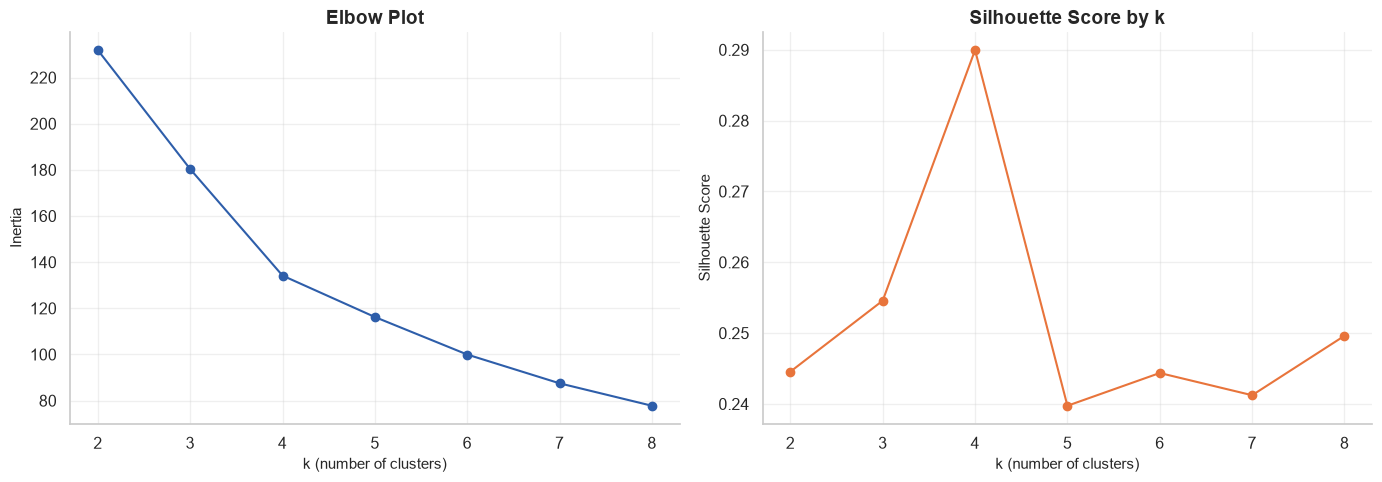

Silhouette scores by k: {2: 0.2446, 3: 0.2546, 4: 0.29, 5: 0.2397, 6: 0.2444, 7: 0.2412, 8: 0.2496}
Best k by silhouette score: 4

CATEGORY CLUSTER PROFILE (k=4)


,total_revenue,avg_review_score,freight_pct_of_revenue,category_repeat_rate_pct,categories
cluster,,,,,
3,"432,437.50",4.12,12.66,0.96,33
1,"30,725.03",4.25,18.43,0.62,34
2,"24,675.67",4.04,23.54,6.33,4
0,"1,994.22",3.18,9.42,0.00,3



CATEGORIES PER CLUSTER
Cluster 0 (3 categories): portable_kitchen_food_preparators, gaming_pc, security_and_services
Cluster 1 (34 categories): electronics, luggage_accessories, furniture_living_room, kitchen_dining_laundry_garden_furniture, books_general_interest, construction_tools_lights, industry_commerce_and_business, food, market_place, costruction_tools_garden, fashion_shoes, signaling_and_security, art, drinks, furniture_bedroom...
Cluster 2 (4 categories): home_appliances, arts_and_craftmanship, diapers_and_hygiene, home_comfort_2
Cluster 3 (33 categories): health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories, furniture_decor, housewares, cool_stuff, auto, garden_tools, toys, baby, perfumery, telephony, office_furniture...


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ['total_revenue', 'avg_review_score', 'freight_pct_of_revenue', 'category_repeat_rate_pct']
cat_features = product_affinity[cluster_features].copy()
cat_features['total_revenue'] = np.log1p(cat_features['total_revenue'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cat_features)

k_range = range(2, 9)
inertias = []
silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', color=PALETTE[0])
axes[0].set_title('Elbow Plot')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color=PALETTE[1])
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"Silhouette scores by k: {dict(zip(k_range, [round(s, 4) for s in silhouette_scores]))}")
print(f"Best k by silhouette score: {best_k}")

final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
product_affinity['cluster'] = final_km.fit_predict(X_scaled)

cluster_profile = product_affinity.groupby('cluster')[cluster_features].mean().round(2)
cluster_profile['categories'] = product_affinity['cluster'].value_counts()
cluster_profile = cluster_profile.sort_values('total_revenue', ascending=False)

print("\n" + "=" * 70)
print(f"CATEGORY CLUSTER PROFILE (k={best_k})")
print("=" * 70)
display(cluster_profile)

print("\n" + "=" * 70)
print("CATEGORIES PER CLUSTER")
print("=" * 70)
for c in sorted(product_affinity['cluster'].unique()):
    cats = product_affinity.loc[product_affinity['cluster'] == c, 'category'].tolist()
    print(f"Cluster {c} ({len(cats)} categories): {', '.join(cats[:15])}{'...' if len(cats) > 15 else ''}")

**Finding:** Best k=4 (silhouette 0.29) reveals four distinct category profiles:

- **Cluster 3 (33 categories, the platform's revenue core)** — `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, `computers_accessories`, `furniture_decor`, and (notably) `office_furniture`. High revenue (BRL 432,437.50 avg), solid reviews (4.12), moderate freight (12.66%), but low repeat rate (0.96%) — these categories drive the business but don't build loyalty. Since `office_furniture` sits here rather than in a low-review cluster, its poor individual review score doesn't appear to be a structural feature shared by this group — consistent with Section 3's finding that its problem is delivery time, not something this cluster's other members share.
- **Cluster 1 (34 categories, small revenue, well-reviewed)** — `electronics`, `furniture_living_room`, `books_general_interest`, and others. Low revenue (BRL 30,725.03 avg) but the *best* average review score of any cluster (4.25), highest freight share (18.43%), and a low repeat rate (0.62%).
- **Cluster 2 (4 categories, small but sticky)** — `home_appliances`, `arts_and_craftmanship`, `diapers_and_hygiene`, `home_comfort_2`. Low revenue (BRL 24,675.67 avg), decent reviews (4.04), and by far the best repeat rate of any cluster (6.33% — roughly 6–10× every other cluster) — a small group that actually builds loyalty.
- **Cluster 0 (3 categories, genuine trouble spot)** — `portable_kitchen_food_preparators`, `gaming_pc`, `security_and_services`. Lowest revenue (BRL 1,994.22 avg), lowest review score of any cluster (3.18), and zero repeat purchases (0.00%) — this is the actual underperforming cluster.

**Practical takeaway:** category clustering reveals no overlap between the categories that drive revenue (Cluster 3), the categories with the best reviews (Cluster 1), and the categories that build repeat customers (Cluster 2) — three almost entirely separate groups. The genuinely troubled cluster (Cluster 0) is small and low-volume, not `office_furniture`'s group; `office_furniture`'s individual problem remains best explained by delivery time (Section 3), not a shared cluster-level weakness.

## Assumptions & Limitations

- Sections 2-3's `driver_data` caps category/state to the top 15/10 most frequent (rest grouped as "other") to keep the Random Forest interpretable — rare categories/states aren't individually represented.
- Test R² (0.1491) is modest — delivery days dominate what the model *can* explain, but most review-score variation remains unexplained by these five features; unmeasured factors (product quality, packaging, seller behavior) likely matter more.
- Section 4's cross-tabs use first-purchase category/state/payment only, matching Notebook 5's attribution convention, not all-order behavior.
- Section 5's response-time test only covers 1-star reviews that received a response, and only tests repeat purchase as the outcome — it can't rule out other real benefits of fast response (reputation, escalation prevention) that aren't measurable here.
- Section 6's `category_repeat_rate_pct` (from `vw_product_customer_affinity`) is defined differently from Notebook 5's first-purchase-customer repeat rate — comparable only directionally, not numerically.
- Category clustering silhouette scores (~0.23-0.26) are modest — clusters are real but not sharply separated; treat groupings as directional.

Full detail in `docs/08_findings_python.md`.

## Summary

- Delivery time dominates review score even in a multivariate model (81% of Random Forest importance, test R²=0.15) — freight, category, state, and payment collectively add little.
- Freight cost is statistically significant but practically negligible for review score (R²=0.0007) — `office_furniture`'s poor score is a delivery-time problem, not a freight problem.
- Category repeat-rate differences are real and hold consistently across state and payment method — `health_beauty` is structurally low everywhere, `furniture_decor`/`bed_bath_table` structurally higher.
- No data-backed case exists for prioritizing 1-star review response speed as a repeat-purchase lever — fast vs. slow response shows no significant difference (p=0.38).
- Category clustering splits revenue drivers (Cluster 3) from loyalty drivers (Cluster 2) into almost entirely different category sets, and the real trouble cluster is Cluster 0.